In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=yf.download("AAPL",
               start="2022-01-01",
               end="2024-01-01",
               auto_adjust=True)
print("Shape:",df.shape)

[*********************100%***********************]  1 of 1 completed

Shape: (501, 5)


In [4]:
print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== LAST 5 ROWS ===")
print(df.tail())

print("\n=== DATA INFO ===")
print(df.info())

=== FIRST 5 ROWS ===
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  177.939713  178.790267  173.735885  173.853197  104487900
2022-01-04  175.681396  178.848946  175.114365  178.545881   99310400
2022-01-05  171.008270  176.140865  170.734533  175.593390   94537600
2022-01-06  168.153580  171.379785  167.801630  168.837923   96904000
2022-01-07  168.319778  170.245725  167.205273  169.023678   86709100

=== LAST 5 ROWS ===
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2023-12-22  191.433090  193.222829  190.810137  192.995392  37149600
2023-12-26  190.889252  191.719846  190.671713  191.442981  28919300
2023-12-27  190.988098  191.334187  188.951158  190.3

In [5]:
df.columns =df.columns.get_level_values(0)

print(df.columns)
print(df.head(2))

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Price            Close        High         Low        Open     Volume
Date                                                                 
2022-01-03  177.939713  178.790267  173.735885  173.853197  104487900
2022-01-04  175.681396  178.848946  175.114365  178.545881   99310400


In [10]:
print("Missing values:")
print(df.isnull().sum())

print(f"\nDate range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")

Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Date range: 2022-01-03 to 2023-12-29
Total trading days: 501


In [11]:
price =df["Close"]

print(f"Type: {type(price)}")
print(f"Length: {len(price)}")
print(f"First price: ${price.iloc[0]:2f}")
print(f"Last price: ${price.iloc[-1]:2f}")

Type: <class 'pandas.Series'>
Length: 501
First price: $177.939713
Last price: $190.375092


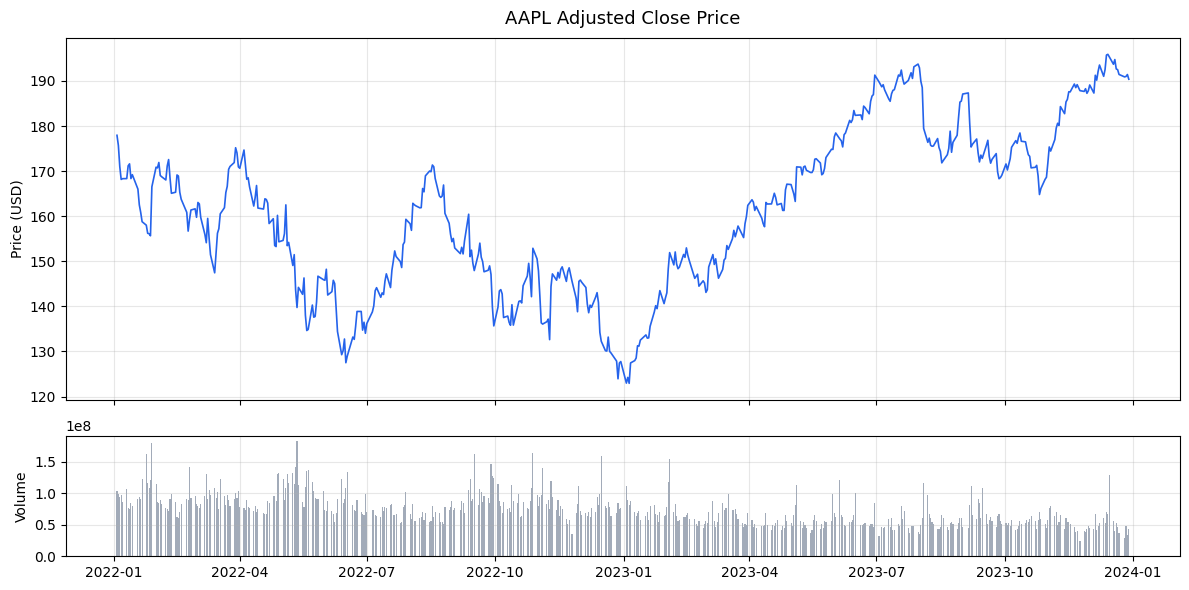

In [14]:
fig, (ax1, ax2) = plt.subplots(
    2,1,
    figsize=(12, 6),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

ax1.plot(price, color='#2563eb', linewidth=1.2)
ax1.set_title('AAPL Adjusted Close Price', fontsize=13, pad=10)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.bar(df.index, df['Volume'], color='#64748b', alpha=0.6)
ax2.set_ylabel('Volume')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

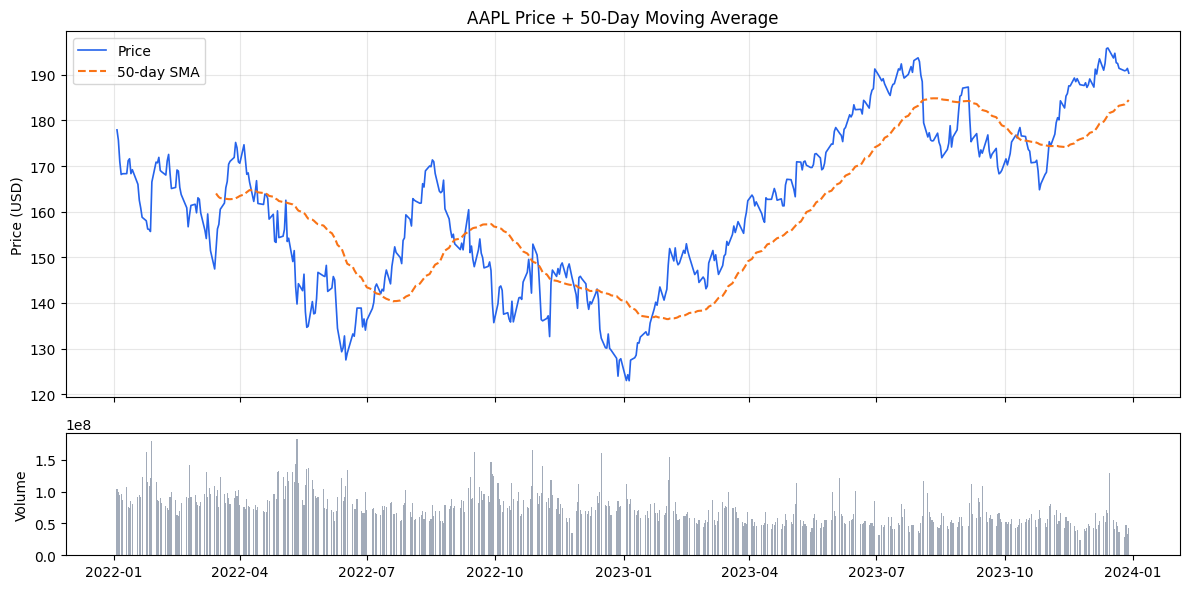

In [17]:
sma50 =price.rolling(window=50).mean()

fig, (ax1, ax2) =plt.subplots(2, 1, figsize=(12,6),
                              gridspec_kw={'height_ratios': [3, 1]},sharex=True)

ax1.plot(price, color='#2563eb', lw=1.2, label='Price')
ax1.plot(sma50, color='#f97316',lw=1.5,
         linestyle='--', label='50-day SMA')
ax1.legend()
ax1.set_title('AAPL Price + 50-Day Moving Average')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.bar(df.index, df['Volume'], color='#64748b', alpha=0.6)
ax2.set_ylabel('Volume')

plt.tight_layout()
plt.show()
                            

In [20]:
log_returns =np.log(price/price.shift(1)).dropna()

mean_daily =log_returns.mean()
std_daily =log_returns.std()
ann_return =mean_daily *252
ann_vol =std_daily *np.sqrt(252)
sharpe =ann_return /ann_vol

print("=" *35)
print("AAPL RETURN SUMMARY (2022-2023)")
print("=" *35)
print(f" Ann. Return : {ann_return:>8.2%}")
print(f" Ann. Volatility : {ann_vol:>8.2%}")
print(f" Sharpe Ratio : {sharpe:>8.2f}")
print(f" Worst Day : {log_returns.min():>8.2%}")
print(f" Best Day : {log_returns.max():>8.2%}")
print("=" *35)

AAPL RETURN SUMMARY (2022-2023)
 Ann. Return :    3.40%
 Ann. Volatility :   29.04%
 Sharpe Ratio :     0.12
 Worst Day :   -6.05%
 Best Day :    8.52%


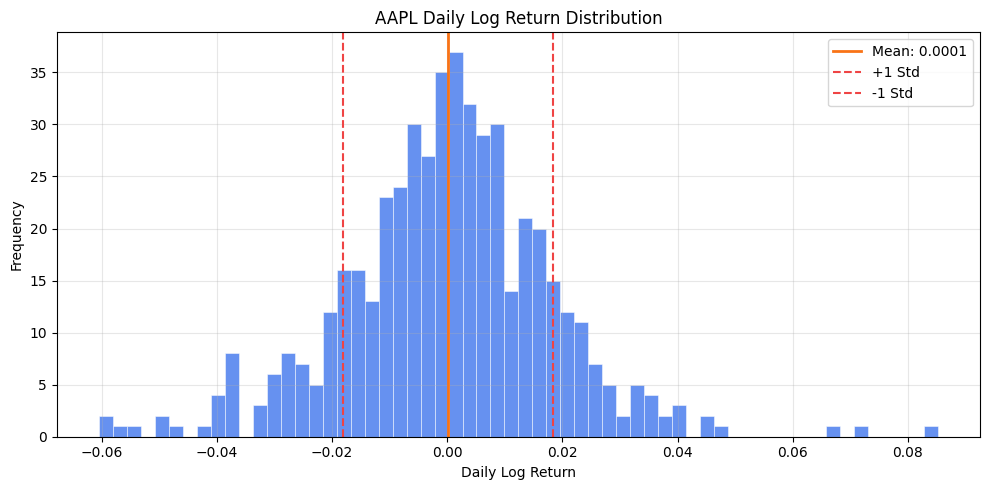

In [22]:
fig, ax =plt.subplots(figsize=(10, 5))

ax.hist(log_returns, bins=60,
        color='#2563eb', alpha=0.7,
        edgecolor='white', linewidth=0.5)

ax.axvline(mean_daily, color='#f97316',
           lw=2, label=f'Mean: {mean_daily:.4f}')
ax.axvline(mean_daily + std_daily, color='#ef4444',
           lw=1.5, linestyle='--', label='+1 Std')
ax.axvline(mean_daily - std_daily, color='#ef4444',
           lw=1.5, linestyle='--', label='-1 Std')

ax.set_title('AAPL Daily Log Return Distribution')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
assets = {"AAPL": log_returns, "SPY": spy_returns}

print(f"{'Metric':<22} {'AAPL':>10} {'SPY':>10}")
print("-" * 44)

results = {}
for name, r in assets.items():
    results[name] = {
        "ann_return": r.mean() * 252,
        "ann_vol":    r.std()  * np.sqrt(252),
        "sharpe":     (r.mean() * 252) / (r.std() * np.sqrt(252))
    }

print(f"{'Ann Return':<22} {results['AAPL']['ann_return']:>10.2%} {results['SPY']['ann_return']:>10.2%}")
print(f"{'Ann Volatility':<22} {results['AAPL']['ann_vol']:>10.2%} {results['SPY']['ann_vol']:>10.2%}")
print(f"{'Sharpe Ratio':<22} {results['AAPL']['sharpe']:>10.2f} {results['SPY']['sharpe']:>10.2f}")
print("-" * 44)

Metric                       AAPL        SPY
--------------------------------------------
Ann Return                  3.40%      1.32%
Ann Volatility             29.04%     19.54%
Sharpe Ratio                 0.12       0.07
--------------------------------------------


In [30]:
def analyze_stock(ticker, start="2022-01-01", end="2024-12-31"):
    """
    Full price dashboard for any ticker.
    Returns a dict of stats and shows price + volume chart.
    """
    # --- Data ---
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price   = df["Close"]
    returns = np.log(price / price.shift(1)).dropna()

    # --- Stats ---
    ann_return = returns.mean() * 252
    ann_vol    = returns.std()  * np.sqrt(252)
    sharpe     = ann_return / ann_vol

    stats = {
        "ticker"       : ticker,
        "ann_return"   : ann_return,
        "ann_vol"      : ann_vol,
        "sharpe"       : sharpe,
        "worst_day"    : returns.min(),
        "best_day"     : returns.max(),
        "total_return" : (price.iloc[-1] / price.iloc[0]) - 1,
    }

    # --- Print summary ---
    print(f"\n{'='*40}")
    print(f"  {ticker} | {start} to {end}")
    print(f"{'='*40}")
    for k, v in stats.items():
        if k == "ticker":
            pass
        elif k == "sharpe":
            print(f"  {k:<20} {v:>8.2f}")
        elif isinstance(v, float):
            print(f"  {k:<20} {v:>8.2%}")

    # --- Chart ---
    sma50 = price.rolling(window=50).mean()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5),
        gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
    ax1.plot(price, lw=1.2, color="#2563eb", label="Price")
    ax1.plot(sma50, lw=1.5, color="#f97316",
             linestyle="--", label="50-day SMA")
    ax1.legend()
    ax1.set_title(f"{ticker} — Ann. Return {ann_return:.1%} | Sharpe {sharpe:.2f}")
    ax1.grid(True, alpha=0.3)
    ax2.bar(df.index, df["Volume"], color="#94a3b8", alpha=0.7)
    ax2.set_ylabel("Volume")
    plt.tight_layout()
    plt.show()

    return stats




[*********************100%***********************]  1 of 1 completed



  AAPL | 2022-01-01 to 2024-12-31
  ann_return             11.49%
  ann_vol                27.06%
  sharpe                   0.42
  worst_day              -6.05%
  best_day                8.52%
  total_return           40.83%


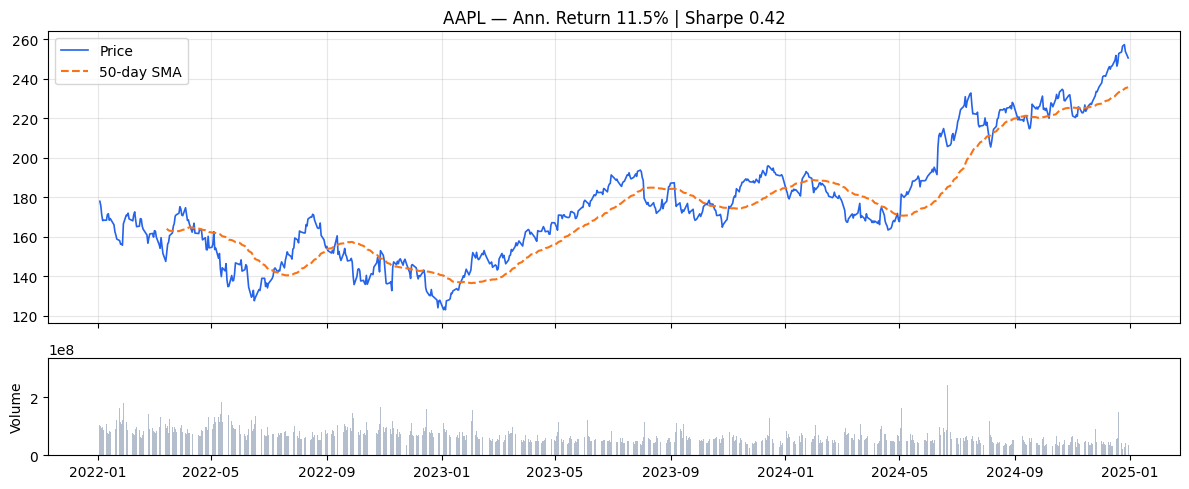

[*********************100%***********************]  1 of 1 completed



  SPY | 2022-01-01 to 2024-12-31
  ann_return              8.46%
  ann_vol                17.53%
  sharpe                   0.48
  worst_day              -4.45%
  best_day                5.35%
  total_return           28.66%


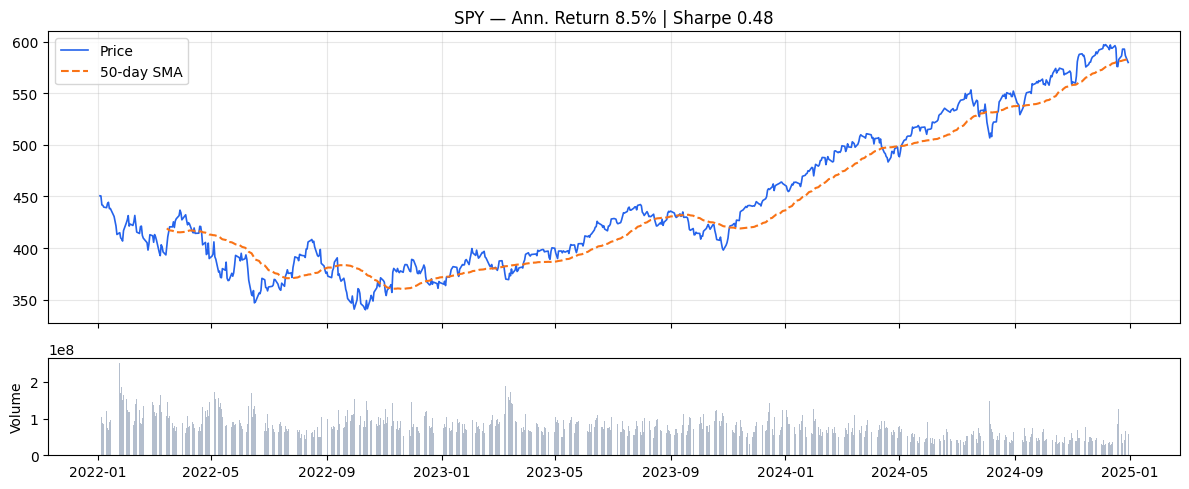

[*********************100%***********************]  1 of 1 completed



  BTC-USD | 2022-01-01 to 2024-12-31
  ann_return             15.30%
  ann_vol                45.20%
  sharpe                   0.34
  worst_day             -17.41%
  best_day               13.58%
  total_return           94.27%


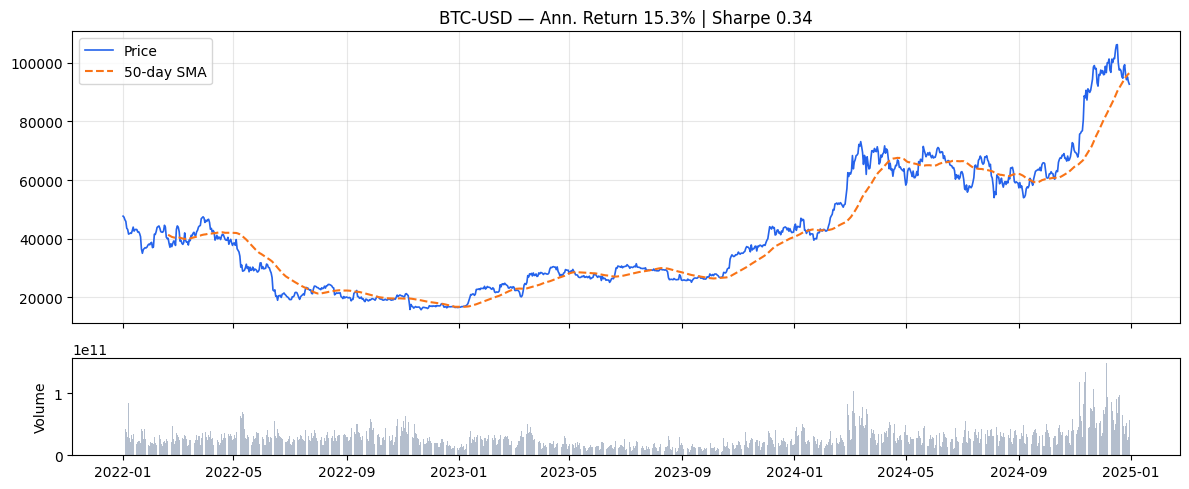

In [31]:
aapl_stats = analyze_stock("AAPL")
spy_stats  = analyze_stock("SPY")
btc_stats  = analyze_stock("BTC-USD")

In [32]:
utils_code = '''import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

def analyze_stock(ticker, start="2022-01-01", end="2024-12-31"):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price   = df["Close"]
    returns = np.log(price / price.shift(1)).dropna()

    ann_return = returns.mean() * 252
    ann_vol    = returns.std()  * np.sqrt(252)
    sharpe     = ann_return / ann_vol

    stats = {
        "ticker"      : ticker,
        "ann_return"  : ann_return,
        "ann_vol"     : ann_vol,
        "sharpe"      : sharpe,
        "worst_day"   : returns.min(),
        "best_day"    : returns.max(),
        "total_return": (price.iloc[-1] / price.iloc[0]) - 1,
    }

    print(f"\\n{'='*40}")
    print(f"  {ticker} | {start} to {end}")
    print(f"{'='*40}")
    for k, v in stats.items():
        if k == "ticker":
            pass
        elif k == "sharpe":
            print(f"  {k:<20} {v:>8.2f}")
        elif isinstance(v, float):
            print(f"  {k:<20} {v:>8.2%}")

    sma50 = price.rolling(window=50).mean()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5),
        gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
    ax1.plot(price, lw=1.2, color="#2563eb", label="Price")
    ax1.plot(sma50, lw=1.5, color="#f97316",
             linestyle="--", label="50-day SMA")
    ax1.legend()
    ax1.set_title(f"{ticker} — Ann. Return {ann_return:.1%} | Sharpe {sharpe:.2f}")
    ax1.grid(True, alpha=0.3)
    ax2.bar(df.index, df["Volume"], color="#94a3b8", alpha=0.7)
    ax2.set_ylabel("Volume")
    plt.tight_layout()
    plt.show()

    return stats
'''

with open("../utils/analyze_stock.py", "w") as f:
    f.write(utils_code)

print("Saved to utils/analyze_stock.py")

Saved to utils/analyze_stock.py
